**HOUSE PRICE- ADVANCED REGRESSION TECHNIQUE**

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
advr=pd.read_csv("/content/creditcard.csv")
print(advr)

        Time        V1        V2        V3        V4        V5        V6  \
0          0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388   
1          0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361   
2          1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499   
3          1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203   
4          2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921   
...      ...       ...       ...       ...       ...       ...       ...   
67429  52531 -0.668025  0.539737  0.161731 -1.071380  1.529141  3.819435   
67430  52532 -0.679169  1.237672  1.602476 -0.007797 -0.228123 -1.095514   
67431  52532 -0.102663  0.890146  1.178701 -0.062896  0.289073 -0.377077   
67432  52532  0.797464 -0.947293  1.045822  0.263474 -1.194980  0.348919   
67433  52534  1.210560  0.291028  0.273319  0.646091 -0.199608 -0.606096   

             V7        V8        V9  ...       V21       V22       V23  \
0      0.2395

In [ ]:
advr.head()
#to see the first part of the data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
advr.info()
#To see the data type and non null count

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67434 entries, 0 to 67433
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    67434 non-null  int64  
 1   V1      67434 non-null  float64
 2   V2      67434 non-null  float64
 3   V3      67434 non-null  float64
 4   V4      67434 non-null  float64
 5   V5      67434 non-null  float64
 6   V6      67434 non-null  float64
 7   V7      67434 non-null  float64
 8   V8      67434 non-null  float64
 9   V9      67434 non-null  float64
 10  V10     67434 non-null  float64
 11  V11     67434 non-null  float64
 12  V12     67434 non-null  float64
 13  V13     67434 non-null  float64
 14  V14     67434 non-null  float64
 15  V15     67434 non-null  float64
 16  V16     67434 non-null  float64
 17  V17     67434 non-null  float64
 18  V18     67434 non-null  float64
 19  V19     67434 non-null  float64
 20  V20     67434 non-null  float64
 21  V21     67433 non-null  float64
 22

In [ ]:
advr.tail()
#to see the last part of the data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
67429,52531,-0.668025,0.539737,0.161731,-1.071380,1.529141,3.819435,-0.685869,1.486179,-0.293208,...,0.214492,0.282335,0.070720,1.022712,-0.505535,0.253658,0.017185,0.105271,49.97,0.0
67430,52532,-0.679169,1.237672,1.602476,-0.007797,-0.228123,-1.095514,0.734340,-0.106748,-0.298766,...,-0.233214,-0.517932,0.020122,0.702798,-0.170477,0.054315,0.380961,0.183103,7.13,0.0
67431,52532,-0.102663,0.890146,1.178701,-0.062896,0.289073,-0.377077,0.753827,0.035692,-0.936965,...,-0.292659,-0.897627,0.275655,0.190260,-0.804461,-0.240939,0.028038,0.029944,9.50,0.0
67432,52532,0.797464,-0.947293,1.045822,0.263474,-1.194980,0.348919,-0.594826,0.268371,0.870239,...,-0.039739,-0.211713,-0.023972,0.313647,-0.045046,0.924183,-0.049685,0.031583,170.82,0.0
67433,52534,1.210560,0.291028,0.273319,0.646091,-0.199608,-0.606096,0.000425,-0.056976,0.051479,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
advr.describe()
#To statistically evaluate like count mean max and min

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,67434.000000,67434.000000,67434.000000,67434.000000,67434.000000,67434.000000,67434.000000,67434.000000,67434.000000,67434.000000,...,67433.000000,67433.000000,67433.000000,67433.000000,67433.000000,67433.000000,67433.000000,67433.000000,67433.000000,67433.000000
mean,33976.974835,-0.241622,-0.018321,0.683462,0.169473,-0.268578,0.101759,-0.114429,0.057624,0.030096,...,-0.028557,-0.106489,-0.038823,0.005627,0.136606,0.020725,0.002811,0.003520,96.628136,0.002506
std,14222.001116,1.857614,1.649726,1.418358,1.377279,1.385175,1.305232,1.251274,1.230082,1.167011,...,0.738014,0.639314,0.608941,0.596550,0.439152,0.497668,0.382484,0.322323,269.895189,0.049999
min,0.000000,-56.407510,-72.715728,-32.965346,-5.172595,-42.147898,-26.160506,-31.764946,-73.216718,-9.283925,...,-34.830382,-10.933144,-26.751119,-2.836627,-7.495741,-2.534330,-8.567638,-9.617915,0.000000,0.000000
25%,28238.000000,-1.001783,-0.590074,0.195636,-0.724684,-0.887468,-0.636482,-0.604414,-0.141812,-0.666519,...,-0.226694,-0.526921,-0.179448,-0.325986,-0.127251,-0.329217,-0.062635,-0.005865,7.680000,0.000000
50%,37354.000000,-0.241551,0.072585,0.772156,0.188286,-0.301379,-0.149794,-0.074146,0.066101,-0.063081,...,-0.061471,-0.081004,-0.051721,0.061460,0.174488,-0.075903,0.009512,0.022750,26.310000,0.000000
75%,44551.000000,1.153782,0.728136,1.405294,1.053095,0.269637,0.494996,0.420850,0.343556,0.688096,...,0.115486,0.309548,0.078955,0.403106,0.422752,0.297957,0.082538,0.075882,88.500000,0.000000
max,52534.000000,1.960497,18.183626,4.226108,16.715537,34.801666,22.529298,36.677268,20.007208,10.392889,...,22.614889,10.503090,17.297845,4.014444,5.525093,3.517346,11.135740,33.847808,19656.530000,1.000000


In [ ]:
advr.shape

(67434, 31)

In [ ]:
print("coloums"),advr.shape[1]

coloums


(None, 31)

In [ ]:
print("rows",advr.shape[0])

rows 67434


In [ ]:
advr.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
67429,False
67430,False
67431,False
67432,False


In [ ]:
advr.duplicated().sum()
#to see the duplicate values

np.int64(0)

In [ ]:
advr=advr.drop_duplicates()
#to get rid of duplicate values

In [ ]:
advr.duplicated().sum()

np.int64(0)

In [ ]:
advr["Amount"]

,Amount
0,149.62
1,2.69
2,378.66
3,123.50
4,69.99
...,...
67429,49.97
67430,7.13
67431,9.50
67432,170.82


In [ ]:
se=StandardScaler()

In [ ]:
advr['Amount']=se.fit_transform(pd.DataFrame(advr['Amount']))
#to standardise data

In [ ]:
advr.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.195305,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.348265,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.042641,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.098674,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.099287,0.0


In [ ]:
advr=advr.drop(['Time'],axis=1)
advr.head()


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.195305,0.0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.348265,0.0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.042641,0.0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.098674,0.0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.099287,0.0


In [ ]:
#to check if its imbalanced
advr['Class'].value_counts()


,count
Class,
0.0,67002
1.0,169


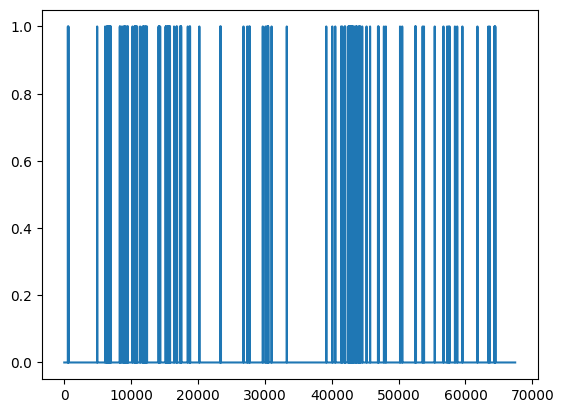

In [ ]:
plt.plot(advr['Class'])
plt.show()

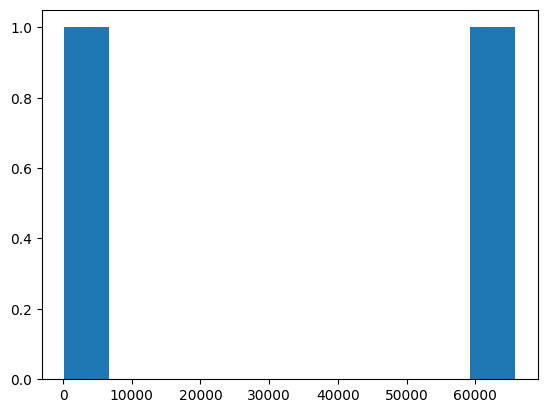

In [ ]:
plt.hist(advr['Class'].value_counts())
plt.show()

In [ ]:
ver = advr['Class'].value_counts()
print(ver)

Class
0.0    65815
1.0      169
Name: count, dtype: int64


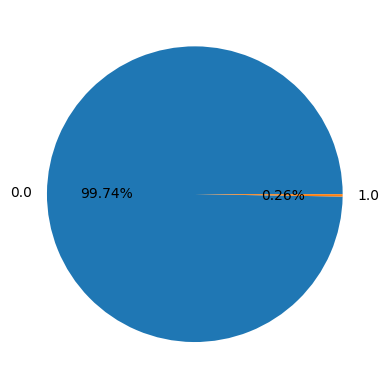

In [ ]:
plt.pie(ver.values,labels=ver.index,autopct='%1.2f%%')
plt.show()
#

In [ ]:
normal=advr[advr['Class']==0]

In [ ]:
normal.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,-2.772272,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,-0.358216,1.0
623,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,-0.838587,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,1.598826,1.0
4920,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,-1.525412,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,0.529408,1.0
6108,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,-4.801637,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,-0.139945,1.0
6329,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,-2.447469,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,-0.354517,1.0


In [ ]:
fraud=advr[advr['Class']==1]
normal.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.195305,0.0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.348265,0.0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.042641,0.0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.098674,0.0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.099287,0.0


In [ ]:
normal.shape

(65815, 30)

In [ ]:
fraud.shape

(169, 30)

In [ ]:
cut=normal.sample(n=169)
cut.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
2051,-1.063267,0.891362,2.340024,-0.458660,-0.928830,-0.927556,0.238078,-0.124532,-0.034687,-0.082739,...,-0.045532,-0.141711,-0.018836,1.002330,-0.258009,1.316983,-0.179204,0.147738,-0.291662,0.0
7544,-0.403756,1.081232,0.772186,0.446872,0.218352,-0.201145,0.071893,-0.105104,0.782673,-0.241922,...,-0.191415,-0.232836,-0.199999,-0.599478,-0.492309,1.073569,-0.527413,-0.280498,-0.354517,0.0
65191,-0.801404,1.041780,2.154167,1.838506,0.524140,0.932956,0.130304,0.348294,-1.272337,0.572565,...,-0.029430,-0.301726,-0.297469,-0.876847,0.127509,0.030173,-0.080358,0.095649,-0.319113,0.0
26706,1.089224,-0.777909,0.641049,0.412301,-0.991179,0.408511,-0.860006,0.302621,-0.773740,0.977632,...,-0.158235,-0.207983,-0.059491,-0.387855,0.244084,-0.269564,0.055656,0.031016,-0.032659,0.0
43885,1.200004,0.308045,0.411739,0.625206,-0.415713,-0.865788,-0.015088,-0.067468,-0.235334,-0.112765,...,-0.223279,-0.682862,0.142923,0.494373,0.157767,0.064530,-0.026778,0.022538,-0.353444,0.0


In [ ]:
normal.shape

(65815, 30)

In [ ]:
newadvr=pd.concat([cut,fraud],ignore_index=True)
newadvr.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.063267,0.891362,2.340024,-0.458660,-0.928830,-0.927556,0.238078,-0.124532,-0.034687,-0.082739,...,-0.045532,-0.141711,-0.018836,1.002330,-0.258009,1.316983,-0.179204,0.147738,-0.291662,0.0
1,-0.403756,1.081232,0.772186,0.446872,0.218352,-0.201145,0.071893,-0.105104,0.782673,-0.241922,...,-0.191415,-0.232836,-0.199999,-0.599478,-0.492309,1.073569,-0.527413,-0.280498,-0.354517,0.0
2,-0.801404,1.041780,2.154167,1.838506,0.524140,0.932956,0.130304,0.348294,-1.272337,0.572565,...,-0.029430,-0.301726,-0.297469,-0.876847,0.127509,0.030173,-0.080358,0.095649,-0.319113,0.0
3,1.089224,-0.777909,0.641049,0.412301,-0.991179,0.408511,-0.860006,0.302621,-0.773740,0.977632,...,-0.158235,-0.207983,-0.059491,-0.387855,0.244084,-0.269564,0.055656,0.031016,-0.032659,0.0
4,1.200004,0.308045,0.411739,0.625206,-0.415713,-0.865788,-0.015088,-0.067468,-0.235334,-0.112765,...,-0.223279,-0.682862,0.142923,0.494373,0.157767,0.064530,-0.026778,0.022538,-0.353444,0.0


In [ ]:
newadvr.shape

(338, 30)

In [ ]:
advr['Class'].value_counts()

,count
Class,
0.0,65815
1.0,169


In [ ]:
#To split class from the rest
x=newadvr.drop('Class',axis=1)
y=newadvr['Class']

In [ ]:
x.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.063267,0.891362,2.340024,-0.458660,-0.928830,-0.927556,0.238078,-0.124532,-0.034687,-0.082739,...,0.197810,-0.045532,-0.141711,-0.018836,1.002330,-0.258009,1.316983,-0.179204,0.147738,-0.291662
1,-0.403756,1.081232,0.772186,0.446872,0.218352,-0.201145,0.071893,-0.105104,0.782673,-0.241922,...,0.158630,-0.191415,-0.232836,-0.199999,-0.599478,-0.492309,1.073569,-0.527413,-0.280498,-0.354517
2,-0.801404,1.041780,2.154167,1.838506,0.524140,0.932956,0.130304,0.348294,-1.272337,0.572565,...,0.063784,-0.029430,-0.301726,-0.297469,-0.876847,0.127509,0.030173,-0.080358,0.095649,-0.319113
3,1.089224,-0.777909,0.641049,0.412301,-0.991179,0.408511,-0.860006,0.302621,-0.773740,0.977632,...,-0.483308,-0.158235,-0.207983,-0.059491,-0.387855,0.244084,-0.269564,0.055656,0.031016,-0.032659
4,1.200004,0.308045,0.411739,0.625206,-0.415713,-0.865788,-0.015088,-0.067468,-0.235334,-0.112765,...,-0.079694,-0.223279,-0.682862,0.142923,0.494373,0.157767,0.064530,-0.026778,0.022538,-0.353444


In [ ]:
y.head()

,Class
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=101)

**RandomForestClassifier**

In [ ]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=44)
rf_model.fit(x_train,y_train)


RandomForestClassifier(random_state=44)

In [ ]:
y_pred=rf_model.predict(x_test)


**MODEL EVALUATION**

In [ ]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy:{accuracy:.2f}")


Accuracy:0.99
